<a href="https://colab.research.google.com/github/JavierAMLC/Laboratorio_UCV_NLP_Sentimientos_UCI_MLP/blob/main/Laboratorio_UCV_NLP_Sentimientos_UCI_MLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# UNIVERSIDAD CÉSAR VALLEJO
## Escuela Profesional de Ingeniería de Sistemas
### LABORATORIO COMPLETO: Análisis de sentimientos usando NLP clásico y Perceptrón Multicapa
**Alumno:** Ramos Alcarraz Jesus Andres

### 1. Preparación del entorno
Esta celda instala las librerías necesarias para el proyecto. La bandera `-q` suprime la salida detallada de la instalación.

In [39]:
%pip install pandas numpy matplotlib scikit-learn requests -q

Note: you may need to restart the kernel to use updated packages.


### 2. Importar librerías
Esta celda importa todas las librerías necesarias para la manipulación de datos, preprocesamiento de texto, modelado de machine learning y visualización de resultados, y establece una semilla para la reproducibilidad de los resultados aleatorios.

In [40]:
import re
import zipfile
import requests
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay,
)

np.random.seed(42)

### 3. Cargar dataset desde UCI
Esta celda define funciones para cargar el conjunto de datos de sentimientos desde UCI. Primero intenta descargar y extraer un archivo ZIP que contiene datos de reseñas de Amazon, IMDb y Yelp. Si la descarga falla, utiliza un pequeño dataset de respaldo. Finalmente, carga el dataset y muestra sus primeras filas.

In [41]:
def load_uci_sentiment_dataset():
    url = 'https://archive.ics.uci.edu/static/public/331/sentiment+labelled+sentences.zip'
    zip_path = Path('sentiment_labelled_sentences.zip')
    extract_dir = Path('sentiment_labelled_sentences')

    response = requests.get(url, timeout=30)
    response.raise_for_status()
    zip_path.write_bytes(response.content)

    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)

    possible_files = [
        extract_dir / 'sentiment labelled sentences' / 'amazon_cells_labelled.txt',
        extract_dir / 'sentiment labelled sentences' / 'imdb_labelled.txt',
        extract_dir / 'sentiment labelled sentences' / 'yelp_labelled.txt',
    ]

    frames = []
    for file_path in possible_files:
        if file_path.exists():
            temp_df = pd.read_csv(
                file_path,
                sep='\t',
                header=None,
                names=['text', 'sentiment'],
                on_bad_lines='skip'
            )
            temp_df['source'] = file_path.stem.replace('_labelled', '')
            frames.append(temp_df)

    if not frames:
        raise FileNotFoundError('No se encontraron archivos del dataset UCI.')

    return pd.concat(frames, ignore_index=True)

def load_fallback_dataset():
    examples = [
        ('I love this product', 1, 'fallback'),
        ('This is an excellent service', 1, 'fallback'),
        ('The movie was amazing', 1, 'fallback'),
        ('The food was delicious', 1, 'fallback'),
        ('I am very happy with the purchase', 1, 'fallback'),
        ('The staff was friendly', 1, 'fallback'),
        ('This phone works perfectly', 1, 'fallback'),
        ('The experience was wonderful', 1, 'fallback'),
        ('I would buy it again', 1, 'fallback'),
        ('Highly recommended', 1, 'fallback'),
        ('I hate this product', 0, 'fallback'),
        ('This is a terrible service', 0, 'fallback'),
        ('The movie was boring', 0, 'fallback'),
        ('The food was awful', 0, 'fallback'),
        ('I am very disappointed', 0, 'fallback'),
        ('The staff was rude', 0, 'fallback'),
        ('This phone does not work', 0, 'fallback'),
        ('The experience was horrible', 0, 'fallback'),
        ('I would never buy it again', 0, 'fallback'),
        ('Not recommended', 0, 'fallback'),
    ]
    return pd.DataFrame(examples, columns=['text', 'sentiment', 'source'])

try:
    df = load_uci_sentiment_dataset()
    print('Dataset UCI cargado correctamente.')
except Exception as error:
    print('No se pudo cargar UCI. Se usará dataset de respaldo.')
    print('Detalle:', error)
    df = load_fallback_dataset()

df.head()

Dataset UCI cargado correctamente.


,text,sentiment,source
0,So there is no way for me to plug it in here i...,0,amazon_cells
1,"Good case, Excellent value.",1,amazon_cells
2,Great for the jawbone.,1,amazon_cells
3,Tied to charger for conversations lasting more...,0,amazon_cells
4,The mic is great.,1,amazon_cells


### 4. Exploración inicial
Esta sección muestra la dimensión del DataFrame, información detallada incluyendo tipos de datos y valores no nulos, y cuenta la ocurrencia de cada sentimiento (0 para negativo, 1 para positivo) y de cada fuente del dataset.

In [42]:
print('Dimensión del dataset:', df.shape)

df.info()

print(df['sentiment'].value_counts().sort_index())

print(df['source'].value_counts())

Dimensión del dataset: (2748, 3)
<class 'pandas.DataFrame'>
RangeIndex: 2748 entries, 0 to 2747
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   text       2748 non-null   str  
 1   sentiment  2748 non-null   int64
 2   source     2748 non-null   str  
dtypes: int64(1), str(2)
memory usage: 64.5 KB
sentiment
0    1362
1    1386
Name: count, dtype: int64
source
amazon_cells    1000
yelp            1000
imdb             748
Name: count, dtype: int64


### 5. Visualizar distribución de clases
Esta celda crea un gráfico de barras para visualizar la distribución de los sentimientos, mostrando cuántas entradas corresponden a sentimiento negativo (0) y cuántas a positivo (1).

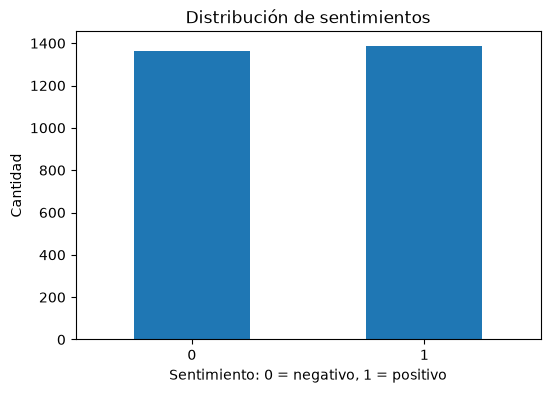

In [43]:
df['sentiment'].value_counts().sort_index().plot(kind='bar', figsize=(6, 4))
plt.title('Distribución de sentimientos')
plt.xlabel('Sentimiento: 0 = negativo, 1 = positivo')
plt.ylabel('Cantidad')
plt.xticks(rotation=0)
plt.show()

### 6. Limpieza de texto
Aquí se define una función para limpiar el texto, que convierte el texto a minúsculas, elimina caracteres no alfabéticos (excepto espacios), y normaliza los espacios. Luego, esta función se aplica a la columna 'text' para crear una nueva columna 'clean_text', y se muestran las primeras 10 filas para comparar el texto original con el texto limpio.

In [44]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text'] = df['text'].apply(clean_text)

df[['text', 'clean_text', 'sentiment']].head(10)

,text,clean_text,sentiment
0,So there is no way for me to plug it in here i...,so there is no way for me to plug it in here i...,0
1,"Good case, Excellent value.",good case excellent value,1
2,Great for the jawbone.,great for the jawbone,1
3,Tied to charger for conversations lasting more...,tied to charger for conversations lasting more...,0
4,The mic is great.,the mic is great,1
5,I have to jiggle the plug to get it to line up...,i have to jiggle the plug to get it to line up...,0
6,If you have several dozen or several hundred c...,if you have several dozen or several hundred c...,0
7,If you are Razr owner...you must have this!,if you are razr owner you must have this,1
8,"Needless to say, I wasted my money.",needless to say i wasted my money,0
9,What a waste of money and time!.,what a waste of money and time,0


### 7. División entrenamiento / prueba
En esta celda, se asignan las características (texto limpio) a `X` y las etiquetas (sentimiento) a `y`. Luego, el dataset se divide en conjuntos de entrenamiento y prueba (70% entrenamiento, 30% prueba), asegurando la reproducibilidad y manteniendo la proporción de clases. Finalmente, se imprimen las dimensiones de los conjuntos resultantes.

In [45]:
X = df['clean_text']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y,
)

print('Train:', X_train.shape)
print('Test :', X_test.shape)

Train: (1923,)
Test : (825,)


### 8. Vectorización con TF-IDF
Esta celda inicializa un `TfidfVectorizer` para convertir texto en características numéricas, limitando a 3000 las características más frecuentes, considerando unigramas y bigramas, y eliminando palabras comunes en inglés. Se ajusta y transforma `X_train`, y luego se transforma `X_test` para evitar fuga de datos. Finalmente, se imprimen las dimensiones de las matrices TF-IDF resultantes.

In [46]:
tfidf = TfidfVectorizer(
    max_features=3000,
    ngram_range=(1, 2),
    stop_words='english',
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print('Matriz entrenamiento:', X_train_tfidf.shape)
print('Matriz prueba       :', X_test_tfidf.shape)

Matriz entrenamiento: (1923, 3000)
Matriz prueba       : (825, 3000)


### 9. Palabras más relevantes por TF-IDF
Aquí se obtienen los nombres de las características (palabras/n-gramas) aprendidas por el `TfidfVectorizer`. Se calcula el TF-IDF medio para cada característica en el conjunto de entrenamiento y se identifican los índices de las 20 características con los valores TF-IDF medios más altos. Finalmente, se muestra un DataFrame con los términos más relevantes y sus TF-IDF medios.

In [47]:
feature_names = np.array(tfidf.get_feature_names_out())

tfidf_means = np.asarray(X_train_tfidf.mean(axis=0)).ravel()

top_indices = tfidf_means.argsort()[-20:][::-1]

pd.DataFrame({
    'term': feature_names[top_indices],
    'mean_tfidf': tfidf_means[top_indices],
})

,term,mean_tfidf
0,great,0.022386
1,good,0.021996
2,phone,0.018970
3,movie,0.015294
4,place,0.014083
5,film,0.012830
6,service,0.012071
7,food,0.011416
8,just,0.010910
9,really,0.010839


### 10. Entrenamiento del Perceptrón Multicapa (MLP)
Esta celda inicializa un clasificador Perceptrón Multicapa (MLP) con dos capas ocultas (64 y 32 neuronas), activación ReLU, y el optimizador Adam. Se configura con un máximo de 300 iteraciones, `random_state=42` para reproducibilidad y `early_stopping=True` para detener el entrenamiento si el rendimiento no mejora. Luego, el modelo se entrena con los datos de entrenamiento TF-IDF y sus etiquetas.

In [48]:
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=300,
    random_state=42,
    early_stopping=True,
)

mlp.fit(X_train_tfidf, y_train)
print('Entrenamiento finalizado.')

Entrenamiento finalizado.


### 11. Evaluación del modelo
Aquí se realizan predicciones sobre el conjunto de prueba utilizando el modelo MLP entrenado. Se calculan y se imprimen varias métricas de evaluación, como Accuracy, Precision, Recall y F1-score. Además, se muestra un informe de clasificación completo que detalla el rendimiento para cada clase (Negativo y Positivo).

In [49]:
y_pred = mlp.predict(X_test_tfidf)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f'Accuracy : {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall   : {recall:.4f}')
print(f'F1-score : {f1:.4f}')

print(classification_report(
    y_test,
    y_pred,
    target_names=['Negativo', 'Positivo']
))

Accuracy : 0.7891
Precision: 0.7630
Recall   : 0.8438
F1-score : 0.8014
              precision    recall  f1-score   support

    Negativo       0.82      0.73      0.78       409
    Positivo       0.76      0.84      0.80       416

    accuracy                           0.79       825
   macro avg       0.79      0.79      0.79       825
weighted avg       0.79      0.79      0.79       825



### 12. Matriz de confusión
Esta celda dibuja la matriz de confusión para visualizar el rendimiento del clasificador, mostrando el número de verdaderos positivos, verdaderos negativos, falsos positivos y falsos negativos.

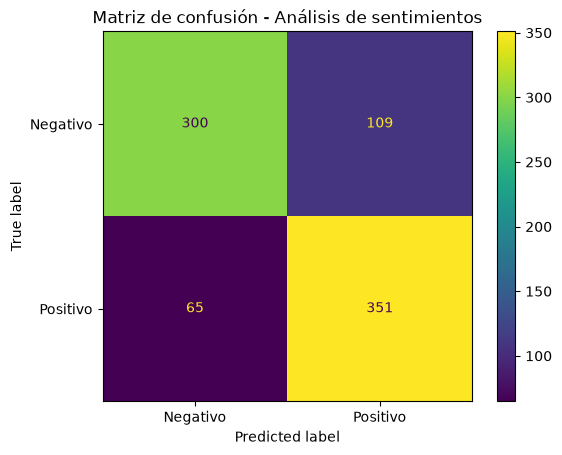

In [50]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=['Negativo', 'Positivo'],
)
plt.title('Matriz de confusión - Análisis de sentimientos')
plt.show()

### 13. Curva de pérdida del MLP
Esta celda crea un gráfico para visualizar la curva de pérdida durante el entrenamiento del MLP, lo cual ayuda a entender cómo el modelo aprende y converge.

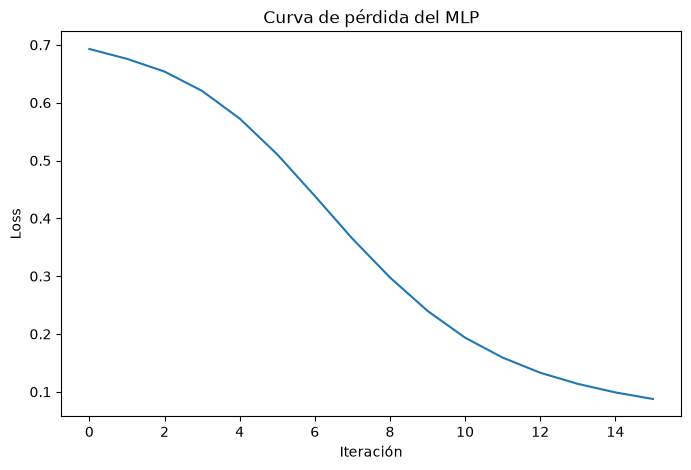

In [51]:
plt.figure(figsize=(8, 5))
plt.plot(mlp.loss_curve_)
plt.title('Curva de pérdida del MLP')
plt.xlabel('Iteración')
plt.ylabel('Loss')
plt.show()

### 14. Predicciones con comentarios nuevos
Aquí se define una función `predict_sentiment` que limpia, vectoriza y predice el sentimiento (positivo o negativo) de un comentario, junto con sus probabilidades. Luego, se utiliza esta función para evaluar una lista de nuevos comentarios y se muestran los resultados en un DataFrame.

In [52]:
def predict_sentiment(comment):
    cleaned = clean_text(comment)
    vectorized = tfidf.transform([cleaned])
    prediction = mlp.predict(vectorized)[0]
    probability = mlp.predict_proba(vectorized)[0]

    label = 'Positivo' if prediction == 1 else 'Negativo'

    return {
        'comment': comment,
        'cleaned': cleaned,
        'prediction': label,
        'negative_probability': probability[0],
        'positive_probability': probability[1],
    }

new_comments = [
    'I love this product, it is amazing',
    'The service was terrible and slow',
    'The movie was not good',
    'Excellent quality and very friendly staff',
    'I will never buy this again',
]

pd.DataFrame([predict_sentiment(comment) for comment in new_comments])

,comment,cleaned,prediction,negative_probability,positive_probability
0,"I love this product, it is amazing",i love this product it is amazing,Positivo,0.331362,0.668638
1,The service was terrible and slow,the service was terrible and slow,Negativo,0.614841,0.385159
2,The movie was not good,the movie was not good,Positivo,0.375972,0.624028
3,Excellent quality and very friendly staff,excellent quality and very friendly staff,Positivo,0.347684,0.652316
4,I will never buy this again,i will never buy this again,Negativo,0.548299,0.451701


### 15. Análisis de errores
Esta celda crea un DataFrame para analizar los errores de predicción, combinando el texto original del conjunto de prueba con los sentimientos reales y los predichos. Luego, filtra y muestra solo las entradas donde la predicción difiere del sentimiento real, mostrando las primeras 10 entradas de los errores.

In [53]:
error_df = pd.DataFrame({
    'text': X_test.values,
    'real': y_test.values,
    'predicted': y_pred,
})

error_df = error_df[error_df['real'] != error_df['predicted']]

error_df.head(10)

,text,real,predicted
2,the tables outside are also dirty a lot of the...,0,1
18,i advise you to look out for it,1,0
19,he came running after us when he realized my h...,1,0
27,it was a long time that i didn t see a so char...,1,0
38,the cast of veteran actors are more than just ...,1,0
47,doesn t do the job,0,1
49,i immediately said i wanted to talk to the man...,0,1
53,con spotty service,0,1
63,i had ordered a motorola data cable got a very...,1,0
64,during several different minute calls i experi...,0,1


### 16. Comparación de arquitecturas (Reto MIT)
Esta celda define y compara diferentes arquitecturas de capas ocultas para el MLP. Itera sobre cada arquitectura, entrena un MLP, realiza predicciones y evalúa el rendimiento, almacenando los resultados en un DataFrame. Finalmente, crea un gráfico de barras para comparar métricas como accuracy, precision, recall y f1_score de cada arquitectura.

    architecture  accuracy  precision    recall  f1_score  iterations
0          (16,)  0.793939   0.810606  0.771635  0.790640          19
1       (64, 32)  0.789091   0.763043  0.843750  0.801370          16
2  (128, 64, 32)  0.784242   0.819892  0.733173  0.774112          15


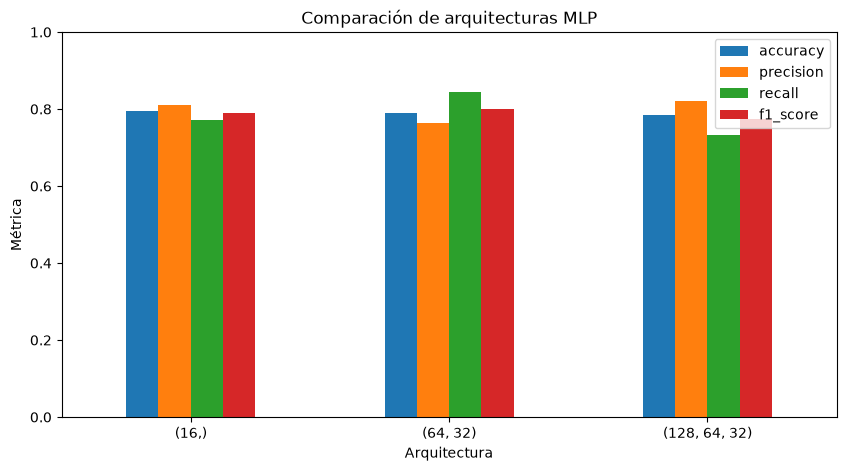

In [54]:
architectures = [
    (16,),
    (64, 32),
    (128, 64, 32),
]

results = []
for architecture in architectures:
    model = MLPClassifier(
        hidden_layer_sizes=architecture,
        activation='relu',
        solver='adam',
        max_iter=300,
        random_state=42,
        early_stopping=True,
    )

    model.fit(X_train_tfidf, y_train)
    predictions = model.predict(X_test_tfidf)

    results.append({
        'architecture': str(architecture),
        'accuracy': accuracy_score(y_test, predictions),
        'precision': precision_score(y_test, predictions),
        'recall': recall_score(y_test, predictions),
        'f1_score': f1_score(y_test, predictions),
        'iterations': model.n_iter_,
    })

results_df = pd.DataFrame(results)
print(results_df)

results_df.plot(
    x='architecture',
    y=['accuracy', 'precision', 'recall', 'f1_score'],
    kind='bar',
    figsize=(10, 5),
)
plt.title('Comparación de arquitecturas MLP')
plt.xlabel('Arquitectura')
plt.ylabel('Métrica')
plt.ylim(0, 1) # Establece el límite del eje y de 0 a 1 para las métricas.
plt.xticks(rotation=0)
plt.show()

### 17. Modelo completo usando Pipeline
Aquí se crea un `Pipeline` que encadena el preprocesamiento TF-IDF y el clasificador MLP, facilitando la aplicación de la secuencia de pasos de preprocesamiento y modelado. El `TfidfVectorizer` dentro del pipeline incluye la función `clean_text` para limpiar el texto directamente, y el pipeline completo se entrena con los datos de entrenamiento originales (sin limpiar).

In [55]:
final_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=3000,
        ngram_range=(1, 2),
        stop_words='english',
        preprocessor=clean_text,
    )),
    ('mlp', MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation='relu',
        solver='adam',
        max_iter=300,
        random_state=42,
        early_stopping=True,
    ))
])

final_pipeline.fit(X_train, y_train)
print('Pipeline final entrenado.')

Pipeline final entrenado.


### 18. Guardar el modelo
Esta celda importa la librería `joblib` y guarda el `final_pipeline` entrenado en un archivo `.joblib`, lo que permite cargar el modelo en el futuro sin necesidad de reentrenarlo.

In [56]:
import joblib

joblib.dump(final_pipeline, 'sentiment_mlp_pipeline.joblib')
print('Modelo guardado como sentiment_mlp_pipeline.joblib')

Modelo guardado como sentiment_mlp_pipeline.joblib


### 19. Prueba final del Pipeline guardable
En esta celda, se define una lista de comentarios de ejemplo y se utiliza el `final_pipeline` guardado para predecir el sentimiento de cada uno. Finalmente, se itera sobre los comentarios y sus predicciones, imprimiendo el comentario original y el sentimiento predicho (Positivo o Negativo).

In [57]:
sample_comments = [
    'The product is wonderful',
    'The product is awful',
    'The service was fast and excellent',
    'I am disappointed with the quality',
]

pipeline_predictions = final_pipeline.predict(sample_comments)

for comment, prediction in zip(sample_comments, pipeline_predictions):
    label = 'Positivo' if prediction == 1 else 'Negativo'
    print(f'{comment} -> {label}')

The product is wonderful -> Positivo
The product is awful -> Negativo
The service was fast and excellent -> Positivo
I am disappointed with the quality -> Negativo
